In [1]:
# Cell 1 - Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 2 - Install libraries
# Pin numpy<2 to avoid binary-compat errors with wheels built against NumPy 1.x.
# Avoid forcing a specific torch build in Colab (GPU/CPU + CUDA must match the runtime).

!pip uninstall -y -q sentence-transformers

# Force NumPy downgrade/lock (common fix for "compiled against NumPy 1.x" errors)
!pip install -q --force-reinstall --no-cache-dir --progress-bar off numpy==1.26.4

!pip install -q --progress-bar off \
  transformers==4.40.0 \
  scikit-learn==1.4.2 \
  fairlearn==0.10.0 \
  aif360==0.6.1 \
  pandas==2.2.1 \
  matplotlib==3.8.4 \
  seaborn==0.13.2

# Verify NumPy version on disk (fresh Python process)
!python -c "import numpy as np; print('numpy (fresh proc):', np.__version__)"

# Sanity-check versions in the current kernel
import numpy as np
import torch
import transformers

print('numpy (kernel):', np.__version__)
print('torch:', torch.__version__)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('transformers:', transformers.__version__)

# If torchvision/torchaudio are installed but expect a different torch version, they can spam resolver warnings.
# We don't need them for text classification, so remove them when they are clearly mismatched.
try:
    import torchvision
    tv = torchvision.__version__
except Exception:
    tv = None

try:
    import torchaudio
    ta = torchaudio.__version__
except Exception:
    ta = None

torch_v = torch.__version__

# Known pairing: torchvision 0.25.* <-> torch 2.10.* (common in recent Colab images)
if (tv and tv.startswith('0.25')) and (not torch_v.startswith('2.10')):
    print(f"Detected mismatch: torchvision=={tv} but torch=={torch_v}. Uninstalling torchvision/torchaudio to prevent conflicts.")
    !pip uninstall -y -q torchvision torchaudio

if (ta and ta.startswith('2.10')) and (not torch_v.startswith('2.10')):
    print(f"Detected mismatch: torchaudio=={ta} but torch=={torch_v}. Uninstalling torchaudio to prevent conflicts.")
    !pip uninstall -y -q torchaudio

# If the kernel still has NumPy 2.x loaded, you MUST restart the runtime/kernel.
# In Colab we can auto-restart by killing the current process.
if int(np.__version__.split('.')[0]) >= 2:
    try:
        import google.colab  # type: ignore
        print('NumPy 2.x is loaded in-kernel. Auto-restarting Colab runtime now...')
        import os
        import signal
        os.kill(os.getpid(), signal.SIGKILL)
    except Exception:
        raise RuntimeError(
            'NumPy 2.x is still loaded in this kernel. Restart the runtime/kernel, then rerun all cells from the top.'
        )

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.1 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.8.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.2

In [3]:
# Cell 3 - Unzip the files (only need to do this ONCE, first notebook only)
import os

zip_train = '/content/drive/MyDrive/jigsaw/jigsaw-unintended-bias-train.csv.zip'
zip_val   = '/content/drive/MyDrive/jigsaw/validation.csv.zip'
out_dir   = '/content/jigsaw/'

os.makedirs(out_dir, exist_ok=True)

train_csv = os.path.join(out_dir, 'jigsaw-unintended-bias-train.csv')
val_csv   = os.path.join(out_dir, 'validation.csv')

if not (os.path.exists(train_csv) and os.path.exists(val_csv)):
    !unzip -q "{zip_train}" -d "{out_dir}"
    !unzip -q "{zip_val}"   -d "{out_dir}"
else:
    print('Already extracted; skipping unzip.')

print('Files extracted:')
!ls /content/jigsaw/

Already extracted; skipping unzip.
Files extracted:
jigsaw-unintended-bias-train.csv  validation.csv


In [4]:
# Cell 4 - Set paths
DATA_PATH = '/content/jigsaw/jigsaw-unintended-bias-train.csv'
VAL_PATH  = '/content/jigsaw/validation.csv'

In [5]:
# Load + prepare dataset
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = '/content/jigsaw/jigsaw-unintended-bias-train.csv'

# Required final columns
final_cols = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'lgbtq']

# Inspect header to robustly handle datasets that don't have a literal 'lgbtq' column
all_cols = list(pd.read_csv(DATA_PATH, nrows=0).columns)

base_cols = ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish']
missing_base = [c for c in base_cols if c not in all_cols]
if missing_base:
    raise ValueError(f"Missing required columns in CSV: {missing_base}. Available columns include: {all_cols[:50]}")

# If 'lgbtq' isn't present, derive it from common identity columns (max across those present)
lgbtq_candidates = [
    'lgbtq',
    'homosexual_gay_or_lesbian',
    'bisexual',
    'transgender',
    'other_sexual_orientation',
]

present_lgbtq_cols = [c for c in lgbtq_candidates if c in all_cols and c != 'lgbtq']

if 'lgbtq' in all_cols:
    usecols = base_cols + ['lgbtq']
    df = pd.read_csv(DATA_PATH, usecols=usecols)
else:
    if not present_lgbtq_cols:
        raise ValueError(
            "Column 'lgbtq' not found and none of the fallback columns were found. "
            f"Tried: {lgbtq_candidates[1:]}. Available columns include: {all_cols[:50]}"
        )
    usecols = base_cols + present_lgbtq_cols
    df = pd.read_csv(DATA_PATH, usecols=usecols)
    df['lgbtq'] = df[present_lgbtq_cols].max(axis=1)

# Keep only the requested columns (ensures 'lgbtq' exists and drops any fallback columns)
df = df[final_cols]

# Drop null comments
df = df.dropna(subset=['comment_text']).copy()

# Binary label
# 1 if toxic >= 0.5 else 0
df['toxic_label'] = (df['toxic'] >= 0.5).astype(int)

# Class balance summary
counts = df['toxic_label'].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)

print('toxic_label value_counts:')
print(counts)
print('\nClass percentages (%):')
print(pct)

# Stratified split with fixed sizes
train_df, eval_df = train_test_split(
    df,
    train_size=100_000,
    test_size=20_000,
    stratify=df['toxic_label'],
    random_state=42,
)

def print_split_stats(name: str, split_df: pd.DataFrame) -> None:
    c = split_df['toxic_label'].value_counts().sort_index()
    p = (c / c.sum() * 100).round(2)
    print(f"\n{name} shape: {split_df.shape}")
    print(f"{name} toxic_label distribution:")
    print(c)
    print(f"{name} toxic_label percentages (%):")
    print(p)

print_split_stats('train_df', train_df)
print_split_stats('eval_df', eval_df)


toxic_label value_counts:
toxic_label
0    1750080
1     152111
Name: count, dtype: int64

Class percentages (%):
toxic_label
0    92.0
1     8.0
Name: count, dtype: float64

train_df shape: (100000, 8)
train_df toxic_label distribution:
toxic_label
0    92003
1     7997
Name: count, dtype: int64
train_df toxic_label percentages (%):
toxic_label
0    92.0
1     8.0
Name: count, dtype: float64

eval_df shape: (20000, 8)
eval_df toxic_label distribution:
toxic_label
0    18401
1     1599
Name: count, dtype: int64
eval_df toxic_label percentages (%):
toxic_label
0    92.01
1     7.99
Name: count, dtype: float64


In [6]:
# Transformers + Torch setup for tokenization
# NOTE: This cell depends on `train_df` and `eval_df` created in the previous data-splitting cell.
required_vars = ['train_df', 'eval_df']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Please run Cells 1–5 in order first (mount/install/unzip/paths + data load/split)."
    )

# Do NOT re-install pinned transformers here; rely on Cell 2 for environment setup.
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')


class ToxicityDataset(Dataset):
    def __init__(self, df):
        # Expects columns: comment_text, toxic_label
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['comment_text'])
        label = int(row['toxic_label'])

        enc = tokenizer(
            text,
            max_length=128,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
        )

        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long),
        }
        return item


# Create datasets from previously-created splits
train_dataset = ToxicityDataset(train_df)
eval_dataset = ToxicityDataset(eval_df)

print('train_dataset length:', len(train_dataset))
print('eval_dataset length:', len(eval_dataset))

sample = train_dataset[0]
print('\nSample keys:', list(sample.keys()))
print('Sample shapes/dtypes:')
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f"- {k}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"- {k}: type={type(v)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

train_dataset length: 100000
eval_dataset length: 20000

Sample keys: ['input_ids', 'attention_mask', 'labels']
Sample shapes/dtypes:
- input_ids: shape=(128,), dtype=torch.int64
- attention_mask: shape=(128,), dtype=torch.int64
- labels: shape=(), dtype=torch.int64


In [7]:
# Train DistilBERT classifier with Hugging Face Trainer
# NOTE: This cell depends on prior cells that create `train_dataset` and `eval_dataset`.
# If you restarted the runtime/kernel, rerun the earlier cells first.

required_vars = ['train_dataset', 'eval_dataset']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Please run Cells 1–6 in order first (mount/install/unzip/paths, data split, dataset/tokenizer)."
    )

# We are not using PEFT here, so remove it to avoid version conflicts.
# Also disable Weights & Biases prompts/logging to keep training non-interactive.
!pip uninstall -y -q peft
!pip install -q --upgrade accelerate

import os
import sys

os.environ["WANDB_DISABLED"] = "true"

# Purge any previously-imported transformers/peft modules (prevents mixed-version import errors)
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('transformers') or mod_name.startswith('peft'):
        del sys.modules[mod_name]

import numpy as np
import torch
import transformers

print('transformers version:', transformers.__version__)

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# fp16 only works on CUDA/accelerators; fall back to fp16=False on CPU runtimes
use_fp16 = torch.cuda.is_available()
if not use_fp16:
    print('CUDA not available -> setting fp16=False (CPU training).')

model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)

    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')

    # ROC-AUC from logits: compute P(class=1) via stable softmax
    logits = logits - logits.max(axis=-1, keepdims=True)
    probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
    probs_pos = probs[:, 1]
    roc_auc = roc_auc_score(labels, probs_pos)

    return {
        'accuracy': acc,
        'f1': f1,
        'roc_auc': roc_auc,
    }


training_args = TrainingArguments(
    output_dir='./checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=200,
    fp16=use_fp16,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

train_output = trainer.train()
print('Final training metrics:')
print(train_output.metrics)

final_eval = trainer.evaluate()
print('\nFinal eval metrics:')
print(final_eval)

trainer.save_model('./saved_model')
print("\nSaved model to ./saved_model")


transformers version: 4.40.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Roc Auc
1,0.147800,0.139267,0.948550,0.808657,0.946623
2,0.110800,0.154538,0.944850,0.809789,0.948819
3,0.072700,0.184748,0.943800,0.803247,0.943390


Final training metrics:
{'train_runtime': 1333.4545, 'train_samples_per_second': 224.98, 'train_steps_per_second': 7.031, 'total_flos': 9935054899200000.0, 'train_loss': 0.1210158369954427, 'epoch': 3.0}



Final eval metrics:
{'eval_loss': 0.1545378863811493, 'eval_accuracy': 0.94485, 'eval_f1': 0.8097888733233646, 'eval_roc_auc': 0.9488193992774206, 'eval_runtime': 27.7042, 'eval_samples_per_second': 721.912, 'eval_steps_per_second': 11.298, 'epoch': 3.0}

Saved model to ./saved_model


Threshold: 0.5
Accuracy: 0.9448
Macro F1: 0.8098
AUC-ROC:  0.9488

Confusion Matrix (rows=true, cols=pred):
           Pred Non-toxic  Pred Toxic
Non-toxic           17875         526
Toxic                 577        1022

Saved figure: roc_pr_curves.png


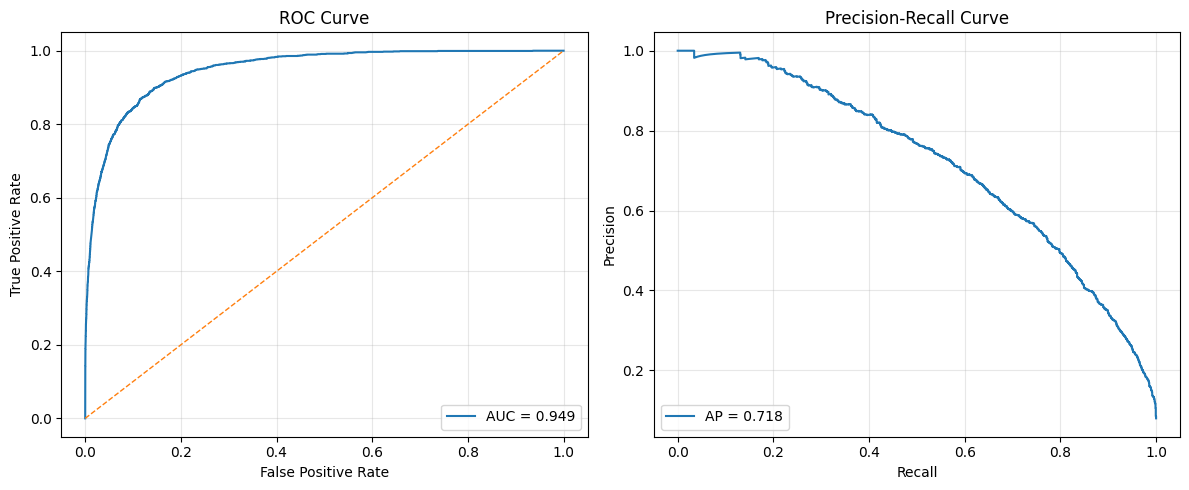

In [8]:
# Predict on eval set + metrics + ROC/PR curves
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

pred_out = trainer.predict(eval_dataset)
logits = pred_out.predictions
y_true = pred_out.label_ids

# Softmax -> probability of class 1 (Toxic)
logits = np.asarray(logits)
logits = logits - logits.max(axis=-1, keepdims=True)  # stability
probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)
probs_pos = probs[:, 1]

threshold = 0.5
y_pred = (probs_pos >= threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
auc = roc_auc_score(y_true, probs_pos)

print(f"Threshold: {threshold}")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"AUC-ROC:  {auc:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Non-toxic', 'Toxic'], columns=['Pred Non-toxic', 'Pred Toxic'])
print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_df)

# Curves
fpr, tpr, _ = roc_curve(y_true, probs_pos)
prec, rec, _ = precision_recall_curve(y_true, probs_pos)
ap = average_precision_score(y_true, probs_pos)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='lower right')

# Precision-Recall
axes[1].plot(rec, prec, label=f"AP = {ap:.3f}")
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=200)
print("\nSaved figure: roc_pr_curves.png")
plt.show()


Threshold sweep (note: ~8% positives; lower thresholds increase recall and false positives):
   threshold precision  recall f1_macro  flagged_toxic_n flagged_toxic_%
0        0.3    0.5837  0.7154   0.8040             1960          9.8000
1        0.4    0.6223  0.6748   0.8077             1734          8.6700
2        0.5    0.6602  0.6391   0.8098             1548          7.7400
3        0.6    0.6937  0.5991   0.8071             1381          6.9050
4        0.7    0.7388  0.5466   0.8003             1183          5.9150

% of comments flagged as toxic at each threshold:
t=0.3: 9.8% | t=0.4: 8.7% | t=0.5: 7.7% | t=0.6: 6.9% | t=0.7: 5.9%


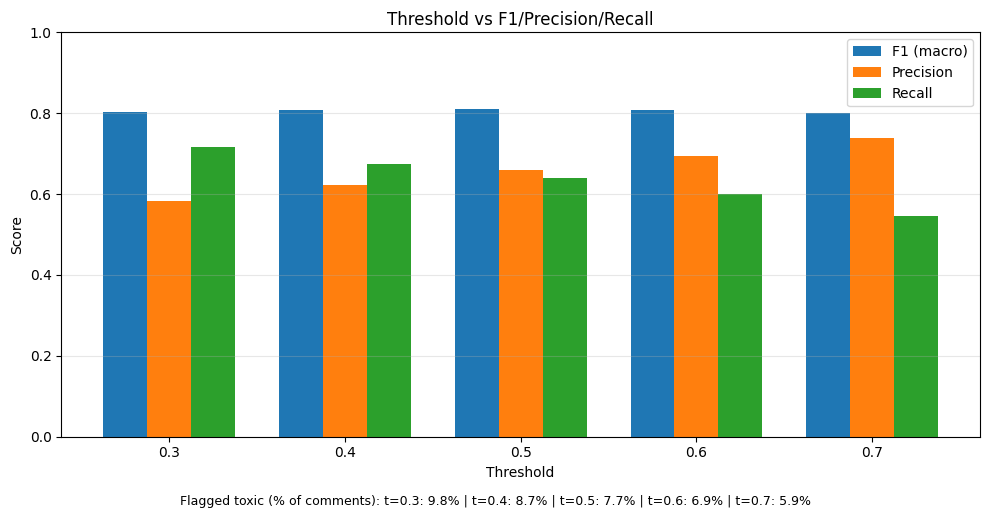

In [9]:
# Threshold sweep: macro F1, Precision, Recall, and % flagged toxic
# Uses `probs_pos` and `y_true` from the previous cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, precision_score, recall_score

required_vars = ["probs_pos", "y_true"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing {missing_vars}. Run the previous evaluation cell first to compute `probs_pos` and `y_true`."
    )

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

rows = []
for thr in thresholds:
    y_pred_thr = (np.asarray(probs_pos) >= thr).astype(int)

    rows.append(
        {
            "threshold": thr,
            "precision": precision_score(y_true, y_pred_thr, pos_label=1, zero_division=0),
            "recall": recall_score(y_true, y_pred_thr, pos_label=1, zero_division=0),
            "f1_macro": f1_score(y_true, y_pred_thr, average="macro", zero_division=0),
            "flagged_toxic_n": int(y_pred_thr.sum()),
            "flagged_toxic_%": float(y_pred_thr.mean() * 100.0),
        }
    )

thr_df = pd.DataFrame(rows)

# Nicely formatted display
show_df = thr_df.copy()
for col in ["precision", "recall", "f1_macro", "flagged_toxic_%"]:
    show_df[col] = show_df[col].map(lambda x: f"{x:.4f}" if isinstance(x, (int, float, np.floating)) else x)

print("Threshold sweep (note: ~8% positives; lower thresholds increase recall and false positives):")
print(show_df)

flag_note = " | ".join(
    [f"t={r['threshold']:.1f}: {r['flagged_toxic_%']:.1f}%" for r in rows]
)
print("\n% of comments flagged as toxic at each threshold:")
print(flag_note)

# Grouped bar chart for metrics
x = np.arange(len(thresholds))
bar_w = 0.25

prec_vals = thr_df["precision"].to_numpy()
rec_vals = thr_df["recall"].to_numpy()
f1_vals = thr_df["f1_macro"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - bar_w, f1_vals, width=bar_w, label="F1 (macro)")
ax.bar(x, prec_vals, width=bar_w, label="Precision")
ax.bar(x + bar_w, rec_vals, width=bar_w, label="Recall")

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Threshold vs F1/Precision/Recall")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")

# Add a note under the plot showing flagged percentages
fig.text(
    0.5,
    -0.02,
    f"Flagged toxic (% of comments): {flag_note}",
    ha="center",
    fontsize=9,
)

plt.tight_layout()
plt.show()


## Threshold choice for the rest of the assignment (recommended: **0.4**)

Based on the F1 / Precision / Recall threshold sweep table, we will use **threshold = 0.4** going forward.

### Why thresholding matters with class imbalance
In this dataset, only about **~8%** of comments are labeled toxic. This is a strong **class imbalance**: a model can get deceptively “good” accuracy by predicting **non-toxic** most of the time. Because the positive class is rare, we have to look beyond accuracy and evaluate **precision/recall/F1** and how many comments get flagged.

### What a *lower* threshold means
A **lower threshold** (e.g., 0.3–0.4) labels more comments as toxic.

- **Pros:** higher **recall** (catches more truly toxic content; fewer harmful comments slip through).
- **Cons:** lower **precision** (more false positives; more non-toxic comments and innocent users get flagged).

### What a *higher* threshold means
A **higher threshold** (e.g., 0.6–0.7) labels fewer comments as toxic.

- **Pros:** higher **precision** (fewer false positives; fewer innocent users flagged).
- **Cons:** lower **recall** (more truly toxic comments are missed, increasing harm and moderation risk).

### Recommendation (social platform): **threshold = 0.4**
For a social platform, I recommend **threshold = 0.4**.

Rationale:
- The cost of **missing toxic content** (false negatives) is typically higher: it can enable harassment, hate, and unsafe community dynamics.
- Over-flagging (false positives) is also harmful, but can be mitigated with secondary review steps (e.g., human moderation, appeals) and tends to be less immediately harmful than letting toxic content remain visible.
- The sweep table shows 0.4 provides a strong **recall-focused** operating point while maintaining reasonable precision and macro F1.

**Decision:** We will use **threshold = 0.4** for the rest of this assignment (metrics, comparisons, and any later fairness analyses).

In [10]:
# Cell 11 - Save trained model + tokenizer (so you don't retrain every time)
# This cell saves to a local folder AND (if available) copies to Google Drive for persistence.

import os
import shutil

# Must have a trained model
required_vars = ["trainer", "tokenizer"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing {missing}. Run the training cell first, then rerun this cell.")

# 1) Always save locally (relative to notebook)
LOCAL_MODEL_DIR = "./saved_model"
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

trainer.save_model(LOCAL_MODEL_DIR)
# Save tokenizer too (Part 2 can reload it from the same directory)
tokenizer.save_pretrained(LOCAL_MODEL_DIR)

print(f"Saved model+tokenizer to: {os.path.abspath(LOCAL_MODEL_DIR)}")

# 2) If running on Colab with Drive mounted, also copy to Drive
DRIVE_ROOT = "/content/drive/MyDrive"
DRIVE_MODEL_DIR = f"{DRIVE_ROOT}/rai_assignment/saved_model"

if os.path.exists(DRIVE_ROOT):
    os.makedirs(os.path.dirname(DRIVE_MODEL_DIR), exist_ok=True)

    # Copy the directory contents (overwrite if it already exists)
    if os.path.exists(DRIVE_MODEL_DIR):
        shutil.rmtree(DRIVE_MODEL_DIR)

    shutil.copytree(LOCAL_MODEL_DIR, DRIVE_MODEL_DIR)
    print(f"Copied saved_model to Google Drive: {DRIVE_MODEL_DIR}")
else:
    print("Google Drive not detected (not running in Colab or Drive not mounted).")

# Optional: store the recommended threshold used in later parts
THRESHOLD = 0.4
with open(os.path.join(LOCAL_MODEL_DIR, "threshold.txt"), "w", encoding="utf-8") as f:
    f.write(str(THRESHOLD))
print(f"Wrote threshold.txt with THRESHOLD={THRESHOLD}")


Saved model+tokenizer to: /content/saved_model
Copied saved_model to Google Drive: /content/drive/MyDrive/rai_assignment/saved_model
Wrote threshold.txt with THRESHOLD=0.4


In [11]:
# Cell 12 - Reload saved model (NO retraining)
# Use this in a fresh runtime to recreate: model, tokenizer, trainer, THRESHOLD.

import os

from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Find saved model directory (local or Drive)
CANDIDATE_MODEL_DIRS = [
    "/content/drive/MyDrive/rai_assignment/saved_model",
    "./saved_model",
]
MODEL_DIR = next((p for p in CANDIDATE_MODEL_DIRS if os.path.isdir(p)), None)
if MODEL_DIR is None:
    raise RuntimeError(
        "Could not find a saved model folder. Expected one of: "
        + ", ".join(CANDIDATE_MODEL_DIRS)
        + ". Train once (Cell 7) and save (Cell 11), then rerun this cell."
    )

print("Reloading model from:", MODEL_DIR)

# Load model + tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

# Load threshold if present
threshold_file = os.path.join(MODEL_DIR, "threshold.txt")
if os.path.exists(threshold_file):
    with open(threshold_file, "r", encoding="utf-8") as f:
        THRESHOLD = float(f.read().strip())
else:
    THRESHOLD = 0.4

print("THRESHOLD:", THRESHOLD)

# Recreate a Trainer for `trainer.predict(...)` usage in later parts
try:
    from transformers import TrainingArguments, Trainer
except Exception as e:
    raise RuntimeError(
        "Failed to import HuggingFace Trainer/TrainingArguments. "
        "This usually means your transformers install is broken/mismatched. "
        "Re-run the install cell (Cell 2) and restart the runtime/kernel, then try again.\n"
        f"Original error: {e}"
    )

args = TrainingArguments(
    output_dir="./tmp_reload",
    per_device_eval_batch_size=64,
    dataloader_drop_last=False,
    report_to="none",
)

trainer = Trainer(model=model, args=args)
print("Reloaded trainer successfully.")


Reloading model from: /content/drive/MyDrive/rai_assignment/saved_model
THRESHOLD: 0.4
Reloaded trainer successfully.
